## Droplet dynamics (Laminar to complex flow transition) - CH only (droplet relaxation)
### Reference: Insights into 2D Navier-Stokes Numerical Simulations, Energy-Conserving Solver Approaches

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
import matplotlib.animation as animation
from skimage import measure

from pathlib import Path
import json
from datetime import datetime

In [2]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain


# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 3*dx
# 0.03
# 4*dx

# Kinematic velocity/viscosity - responsible for turbulent flow
nu = 0
# 0.05
# 4.67e-3

# Friction coefficient
alpha = 0.0
# 1e-3

# Mobility in Cahn-Hilliard equation
M = 1e-05
# 4e-4
# 6e-4
# epsilon**2/2

# Low sigma could break the interface
sigma = 1.0

lamda_01 = -nu*K2 - alpha
lamda_02 = (-3/2)*M*sigma*epsilon*K2**2 + (3/4)*(sigma/epsilon)*M*K2 # M*sigma*epsilon*dt*K**4/2 or 3 must be less than 1, M and dt have inverse relation

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 3.0
# 5.0

# Wavenumber, Decreasing this causes advection, should be an integer
k_f = 4

# Forcing
# f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
# f_w_hat = np.fft.fft2(f_w)

T = 50.0
N_t = 250000
delta_t = 1e-04
# T/N_t
save_every = 100

# Single droplet parameters

xc = 0.35 * L_x
yc = 0.55 * L_y

droplet_radius = 0.10 * L_x  

In [3]:
delta_t

0.0001

In [4]:
experiment_name = "Experiment_DD_CH_test_DR"

def create_experiment_folder(experiment_name, base_dir="Results"):
    """
    Creates:
        Results/<experiment_name>/
    """
    experiment_dir = Path(base_dir) / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    return {
        "experiment_dir": experiment_dir
    }


dirs = create_experiment_folder(experiment_name)

experiment_dir = dirs["experiment_dir"]
plots_dir = experiment_dir
animations_dir = experiment_dir

In [5]:
parameters = {

    # Experiment metadata
    "experiment_name": experiment_name,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "Cahn Hilliard only - Droplet deformation",

    # Domain
    "domain": {
        "dimension": 2,
        "geometry": "periodic square domain",
        "L_x": float(L_x),
        "L_y": float(L_y),
        "N_x": int(N_x),
        "N_y": int(N_y),
        "del_x": float(del_x),
        "del_y": float(del_y),
        "dx": float(dx),
        "grid_points": int(N_x * N_y),
    },

    # Physical parameters
    "physical_parameters": {
        "epsilon": float(epsilon),
        "epsilon_definition": "epsilon = 3 * dx",
        "nu": float(nu),
        "alpha": float(alpha),
        "M": float(M),
        "sigma": float(sigma),
    },


    # Forcing
    "forcing": {
        # "type": "Kolmogorov-type forcing",
        # "reference": "Interface-induced turbulence in viscous binary fluid mixtures, Supplemental Material",
        "f_0": float(f_0),
        "k_f": k_f,
        "definition": "f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))",
    },


    # Time stepping
    "time_stepping": {
        "T": float(T),
        "N_t": int(N_t),
        "delta_t": float(delta_t),
        "save_every": int(save_every),
        "number_of_saved_snapshots": int(N_t // save_every + 1),
    },
}

def save_parameters(parameters, experiment_dir):
    json_path = experiment_dir / "parameters.json"

    # Save JSON
    with open(json_path, "w") as f:
        json.dump(parameters, f, indent=4)

    print(f"Saved parameters to:\n{json_path}")

save_parameters(parameters, experiment_dir)

Saved parameters to:
Results/Experiment_DD_CH_test_DR/parameters.json


In [6]:
def single_droplet_phi(X, Y, xc, yc, R, epsilon):
    """
    Diffuse single-droplet initial condition matching the paper's convention:
        phi < 0 inside droplet
        phi > 0 in background

    Parameters
    ----------
    X, Y : 2D arrays
        Meshgrid arrays.
    xc, yc : float
        Droplet center.
    d0 : float
        Droplet diameter.
    xi : float
        Diffuse interface width parameter from the paper.
    """
    r = np.sqrt((X - xc)**2 + (Y - yc)**2)
    return np.tanh((R - r) / epsilon)

# Initialise phi - Smooth diffuse-interface droplet
# phi ≈ +1 inside droplet, phi ≈ -1 outside droplet
phi_xy_0 = single_droplet_phi(X, Y, xc, yc, droplet_radius, epsilon)
phi_hat_0 = np.fft.fft2(phi_xy_0)

# Initial vorticity
omega_xy_0 = np.zeros((N_y, N_x))
omega_hat = np.fft.fft2(omega_xy_0)

In [7]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

In [8]:
# CH-only linear operator
K4 = K2**2

lambda_phi = (M * sigma / epsilon) * K2 - (M * sigma * epsilon) * K4
lambda_phi = lambda_phi.astype(complex)

E_phi = np.exp(lambda_phi * delta_t)

In [9]:
# ETD2 coefficients for phi equation

mask_phi = np.abs(lambda_phi) > 1e-14

phi1_phi = np.empty_like(lambda_phi, dtype=complex)
phi_1_phi = np.empty_like(lambda_phi, dtype=complex)

phi1_phi[mask_phi] = (E_phi[mask_phi] - 1.0) / lambda_phi[mask_phi]
phi1_phi[~mask_phi] = delta_t

phi_1_phi[mask_phi] = (
    E_phi[mask_phi] - 1.0 - lambda_phi[mask_phi] * delta_t
) / (lambda_phi[mask_phi]**2 * delta_t)

phi_1_phi[~mask_phi] = 0.5 * delta_t

In [10]:
def H_ch_only(phi_hat):
    """
    CH-only nonlinear RHS in Fourier space.

    PDE:
        phi_t = M Delta mu

    with:
        mu = (sigma/epsilon)(phi^3 - phi) - sigma epsilon Delta phi

    Linear part handled by lambda_phi:
        L phi = (M sigma / epsilon) K2 phi_hat
                - (M sigma epsilon) K4 phi_hat

    Nonlinear part:
        N(phi) = -(M sigma / epsilon) K2 FFT(phi^3)
    """

    phi_xy = np.fft.ifft2(phi_hat).real
    nonlinear_hat = -(M * sigma / epsilon) * K2 * np.fft.fft2(phi_xy**3)
    nonlinear_hat = dealias(nonlinear_hat)

    # The nonlinear term should not change the mean.
    nonlinear_hat[0, 0] = 0.0

    return nonlinear_hat

In [11]:

def compute_droplet_area(phi_xy):
    """
    Approximate droplet area using the phi = 0 contour threshold.
    The + phase is considered the droplet.
    """
    return np.mean(phi_xy > 0.0) * L_x * L_y


def compute_droplet_centroid(phi_xy):
    """
    Approximate centroid of the positive phase.
    Works well if the droplet does not cross the periodic boundary.
    """
    mask = phi_xy > 0.0

    if np.sum(mask) == 0:
        return np.nan, np.nan

    area_weights = mask.astype(float)

    cx = np.sum(X * area_weights) / np.sum(area_weights)
    cy = np.sum(Y * area_weights) / np.sum(area_weights)

    return cx, cy


def compute_interface_length(phi_xy):
    """
    Approximate interface length from the phi = 0 contour.
    Uses skimage.measure.find_contours.
    """
    contours = measure.find_contours(phi_xy, level=0.0)

    total_length = 0.0

    for contour in contours:
        y_idx = contour[:, 0]
        x_idx = contour[:, 1]

        x_phys = x_idx * del_x
        y_phys = y_idx * del_y

        dx_c = np.diff(x_phys)
        dy_c = np.diff(y_phys)

        total_length += np.sum(np.sqrt(dx_c**2 + dy_c**2))

    return total_length


def compute_phase_volume(phi_xy):
    """
    Smooth estimate of + phase area.
    For phi ≈ +1 inside and phi ≈ -1 outside,
    positive-phase area is approximately integral((phi + 1)/2).
    """
    return np.mean((phi_xy + 1.0) / 2.0) * L_x * L_y


def chemical_potential(phi_hat):
    """
    Computes chemical potential:
        mu = (sigma/epsilon)(phi^3 - phi) - sigma epsilon Delta phi
    """

    phi_xy = np.fft.ifft2(phi_hat).real
    lap_phi = np.fft.ifft2(-K2 * phi_hat).real
    mu_xy = (sigma / epsilon) * (phi_xy**3 - phi_xy) - sigma * epsilon * lap_phi
    mu_hat = np.fft.fft2(mu_xy)

    return mu_xy, mu_hat


def compute_mass_phi(phi_xy):
    """
    Mean value of phi. For periodic CH, this should be conserved.
    """
    return np.mean(phi_xy)


def compute_free_energy(phi_hat):
    """
    Computes CH free energy density averaged over the domain:

        F = < sigma/(4 epsilon) (phi^2 - 1)^2
              + sigma epsilon / 2 |grad phi|^2 >

    This returns the spatial average, not the integral.
    That is fine for diagnostics.
    """

    phi_xy = np.fft.ifft2(phi_hat).real

    phi_x = np.fft.ifft2(1j * Kx * phi_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_hat).real

    bulk_energy = sigma / (4.0 * epsilon) * (phi_xy**2 - 1.0)**2
    gradient_energy = 0.5 * sigma * epsilon * (phi_x**2 + phi_y**2)

    free_energy = np.mean(bulk_energy + gradient_energy)

    return free_energy


def compute_mu_dissipation(mu_hat):
    """
    Computes CH dissipation:

        D = M < |grad mu|^2 >

    Free energy should satisfy:
        dF/dt = -D
    """

    mu_x = np.fft.ifft2(1j * Kx * mu_hat).real
    mu_y = np.fft.ifft2(1j * Ky * mu_hat).real

    dissipation = M * np.mean(mu_x**2 + mu_y**2)

    return dissipation

def check_finite_fields(**fields):
    """
    Checks whether all provided arrays contain only finite values.
    """
    results = {}

    for name, arr in fields.items():
        results[name] = np.isfinite(arr).all()

    return results

def compute_structure_factor_phi(phi_xy, Lx, Ly):
    Ny, Nx = phi_xy.shape

    # Remove mean mode
    phi0 = phi_xy - np.mean(phi_xy)

    phi_hat = np.fft.fft2(phi0)

    kx = 2.0 * np.pi * np.fft.fftfreq(Nx, d=Lx / Nx)
    ky = 2.0 * np.pi * np.fft.fftfreq(Ny, d=Ly / Ny)

    KX, KY = np.meshgrid(kx, ky, indexing="xy")
    K = np.sqrt(KX**2 + KY**2)

    power = np.abs(phi_hat)**2

    shell_index = np.floor(K).astype(int)
    k_max = shell_index.max()

    S_shell = np.zeros(k_max + 1)

    for k in range(k_max + 1):
        S_shell[k] = np.sum(power[shell_index == k])

    k_shell = np.arange(k_max + 1)

    return k_shell[1:], S_shell[1:]

def compute_coarsening_length_phi(phi_xy, Lx, Ly):
    k, S = compute_structure_factor_phi(phi_xy, Lx, Ly)

    denom = np.sum(k * S)

    if denom <= 1e-14:
        return np.nan

    return 2.0 * np.pi * np.sum(S) / denom

In [12]:

# CH-only histories


phi_history = []
time_history = []

mass_history = []
mass_error_history = []

free_energy_history = []
dissipation_history = []

min_phi_history = []
max_phi_history = []
finite_check_history = []

droplet_area_history = []
droplet_area_error_history = []

centroid_x_history = []
centroid_y_history = []

interface_length_history = []
phase_volume_history = []
phase_volume_error_history = []
L_coarsening_history = []

# Initial diagnostics
phi_xy_initial = np.fft.ifft2(phi_hat_0).real
q_phi_n = phi_hat_0.copy()
mass_initial = compute_mass_phi(phi_xy_initial)
free_energy_initial = compute_free_energy(phi_hat_0)

droplet_area_initial = compute_droplet_area(phi_xy_initial)
phase_volume_initial = compute_phase_volume(phi_xy_initial)

print("Initial mass        =", mass_initial)
print("Initial free energy =", free_energy_initial)


# Time stepping: CH only


for n in range(N_t + 1):

    t = n * delta_t

    phi_xy_n = np.fft.ifft2(q_phi_n).real

    if n % save_every == 0:

        mu_xy_n, mu_hat_n = chemical_potential(q_phi_n)

        mass_n = compute_mass_phi(phi_xy_n)
        mass_error = abs(mass_n - mass_initial)

        free_energy_n = compute_free_energy(q_phi_n)
        dissipation_n = compute_mu_dissipation(mu_hat_n)

        finite_checks = check_finite_fields(
            phi_hat=q_phi_n,
            phi_xy=phi_xy_n,
            mu_xy=mu_xy_n
        )

        droplet_area_n = compute_droplet_area(phi_xy_n)
        area_error_n = abs(droplet_area_n - droplet_area_initial)
        centroid_x_n, centroid_y_n = compute_droplet_centroid(phi_xy_n)
        interface_length_n = compute_interface_length(phi_xy_n)
        phase_volume_n = compute_phase_volume(phi_xy_n)
        phase_volume_error_n = abs(phase_volume_n - phase_volume_initial)

        phase_volume_history.append(phase_volume_n)
        phase_volume_error_history.append(phase_volume_error_n)

        phi_history.append(phi_xy_n.copy())
        time_history.append(t)

        mass_history.append(mass_n)
        mass_error_history.append(mass_error)

        free_energy_history.append(free_energy_n)
        dissipation_history.append(dissipation_n)

        min_phi_history.append(np.min(phi_xy_n))
        max_phi_history.append(np.max(phi_xy_n))

        finite_check_history.append(finite_checks)

        droplet_area_history.append(droplet_area_n)
        droplet_area_error_history.append(area_error_n)
        centroid_x_history.append(centroid_x_n)
        centroid_y_history.append(centroid_y_n)
        interface_length_history.append(interface_length_n)
        
        L_phi_n = compute_coarsening_length_phi(phi_xy_n, L_x, L_y)
        L_coarsening_history.append(L_phi_n)

        print(
            f"step {n}/{N_t}, "
            f"t={t:.4f}, "
            f"mass={mass_n:.8e}, "
            f"mass_err={mass_error:.4e}, "
            f"area={droplet_area_n:.6e}, "
            f"area_err={area_error_n:.4e}, "
            f"F={free_energy_n:.8e}, "
            f"D={dissipation_n:.4e}, "
            f"min(phi)={np.min(phi_xy_n):.4f}, "
            f"max(phi)={np.max(phi_xy_n):.4f}"
        )

        if not all(finite_checks.values()):
            print("Non-finite field detected.")
            print(finite_checks)
            break

    if n == N_t:
        break

    # --------------------------------------------------------
    # ETD2 update for CH equation
    # --------------------------------------------------------

    # RHS at current state
    H_n = H_ch_only(q_phi_n)

    # Predictor
    a_phi_n = q_phi_n * E_phi + H_n * phi1_phi

    # RHS at predictor state
    H_a = H_ch_only(a_phi_n)

    # Corrector
    q_phi_next = a_phi_n + (H_a - H_n) * phi_1_phi

    # Dealias final phi
    q_phi_next = dealias(q_phi_next)

    # Enforce exact mass conservation by preserving zero mode
    q_phi_next[0, 0] = q_phi_n[0, 0]

    # Update
    q_phi_n = q_phi_next

Initial mass        = -0.9364584695917205
Initial free energy = 0.09999999999973548
step 0/250000, t=0.0000, mass=-9.36458470e-01, mass_err=0.0000e+00, area=1.237315e+00, area_err=0.0000e+00, F=1.00000000e-01, D=1.9816e-03, min(phi)=-1.0000, max(phi)=1.0000
step 100/250000, t=0.0100, mass=-9.36458470e-01, mass_err=1.1102e-16, area=1.237315e+00, area_err=0.0000e+00, F=9.99804885e-02, D=1.9418e-03, min(phi)=-1.0002, max(phi)=1.0003
step 200/250000, t=0.0200, mass=-9.36458470e-01, mass_err=1.1102e-16, area=1.237315e+00, area_err=0.0000e+00, F=9.99613652e-02, D=1.9012e-03, min(phi)=-1.0002, max(phi)=1.0003
step 300/250000, t=0.0300, mass=-9.36458470e-01, mass_err=0.0000e+00, area=1.237315e+00, area_err=0.0000e+00, F=9.99426305e-02, D=1.8634e-03, min(phi)=-1.0002, max(phi)=1.0003
step 400/250000, t=0.0400, mass=-9.36458470e-01, mass_err=1.1102e-16, area=1.237315e+00, area_err=0.0000e+00, F=9.99242583e-02, D=1.8281e-03, min(phi)=-1.0002, max(phi)=1.0003
step 500/250000, t=0.0500, mass=-9.364

### Validation:



In [13]:
# Convert histories
time_history = np.array(time_history)
mass_history = np.array(mass_history)
mass_error_history = np.array(mass_error_history)
free_energy_history = np.array(free_energy_history)
dissipation_history = np.array(dissipation_history)
min_phi_history = np.array(min_phi_history)
max_phi_history = np.array(max_phi_history)
L_coarsening_history = np.array(L_coarsening_history)

droplet_area_history = np.array(droplet_area_history)
droplet_area_error_history = np.array(droplet_area_error_history)
centroid_x_history = np.array(centroid_x_history)
centroid_y_history = np.array(centroid_y_history)
interface_length_history = np.array(interface_length_history)
phase_volume_history = np.array(phase_volume_history)
phase_volume_error_history = np.array(phase_volume_error_history)

# Final field
phi_final = np.fft.ifft2(q_phi_n).real
mu_final, mu_hat_final = chemical_potential(q_phi_n)

finite_checks = check_finite_fields(
    phi_hat=q_phi_n,
    phi_xy=phi_final,
    mu_xy=mu_final
)

# Derived final diagnostics
centroid_shift_final = np.sqrt(
    (centroid_x_history[-1] - centroid_x_history[0])**2
    + (centroid_y_history[-1] - centroid_y_history[0])**2
)

interface_length_change = interface_length_history[-1] - interface_length_history[0]
relative_area_error_final = (
    droplet_area_error_history[-1] / droplet_area_history[0]
    if droplet_area_history[0] != 0
    else np.nan
)

relative_interface_length_change = (
    interface_length_change / interface_length_history[0]
    if interface_length_history[0] != 0
    else np.nan
)

print("========== CAHN-HILLIARD ONLY DROPLET TEST ==========")

print("\n1. Mass conservation")
print("Initial mass       =", mass_history[0])
print("Final mass         =", mass_history[-1])
print("Absolute mass error=", mass_error_history[-1])

print("\n2. Free energy decay")
print("Initial free energy =", free_energy_history[0])
print("Final free energy   =", free_energy_history[-1])
print("Energy decrease     =", free_energy_history[0] - free_energy_history[-1])

print("\n3. Chemical-potential dissipation")
print("Initial dissipation =", dissipation_history[0])
print("Final dissipation   =", dissipation_history[-1])

print("\n4. Phi range")
print("Initial min(phi) =", min_phi_history[0])
print("Initial max(phi) =", max_phi_history[0])
print("Final min(phi)   =", min_phi_history[-1])
print("Final max(phi)   =", max_phi_history[-1])

print("\5. Additional check: Mass-based phase volume")
print("Initial phase volume       =", phase_volume_history[0])
print("Final phase volume         =", phase_volume_history[-1])
print("Absolute phase-volume error=", phase_volume_error_history[-1])
print(
    "Relative phase-volume error=",
    phase_volume_error_history[-1] / phase_volume_history[0]
)

print("\n6. Droplet centroid stability")
print("Initial centroid =",
      f"({centroid_x_history[0]}, {centroid_y_history[0]})")
print("Final centroid   =",
      f"({centroid_x_history[-1]}, {centroid_y_history[-1]})")

print("Centroid shift   =", centroid_shift_final)

print("\n7. Interface length relaxation")
print("Initial interface length =", interface_length_history[0])
print("Final interface length   =", interface_length_history[-1])
print("Absolute change          =", interface_length_change)
print("Relative change          =", relative_interface_length_change)

print("\n8. Finite field checks")

for name, status in finite_checks.items():
    print(f"{name}: {status}")

print("\n=====================================================")

========== CAHN-HILLIARD ONLY DROPLET TEST ==========

1. Mass conservation
Initial mass       = -0.9364584695917205
Final mass         = -0.9364584695917206
Absolute mass error= 1.1102230246251565e-16

2. Free energy decay
Initial free energy = 0.09999999999973548
Final free energy   = 0.09506662938466139
Energy decrease     = 0.004933370615074095

3. Chemical-potential dissipation
Initial dissipation = 0.001981553694141648
Final dissipation   = 4.338501582107411e-05

4. Phi range
Initial min(phi) = -1.0000000000000009
Initial max(phi) = 0.9999998956355924
Final min(phi)   = -1.0098412350756036
Final max(phi)   = 1.027362345136388
. Additional check: Mass-based phase volume
Initial phase volume       = 1.2542595363390174
Final phase volume         = 1.254259536339017
Absolute phase-volume error= 4.440892098500626e-16
Relative phase-volume error= 3.540648462169862e-16

6. Droplet centroid stability
Initial centroid = (2.200161608959934, 3.4568608063265)
Final centroid   = (2.200000789

In [14]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    phi_history[0],
    origin="lower",
    extent=[0, L_x, 0, L_y],
    vmin=-1,
    vmax=1,
    animated=True
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\phi$")

title = ax.set_title(f"CH-only phase separation, t = {time_history[0]:.3f}")
ax.set_xlabel("x")
ax.set_ylabel("y")

def update(frame):
    im.set_array(phi_history[frame])
    title.set_text(f"CH-only phase separation, t = {time_history[frame]:.3f}")
    return im, title

anim = FuncAnimation(
    fig,
    update,
    frames=len(phi_history),
    interval=80,
    blit=True
)
anim.save("ch_phase_separation_dr.gif", writer="pillow", fps=15)

plt.close(fig)

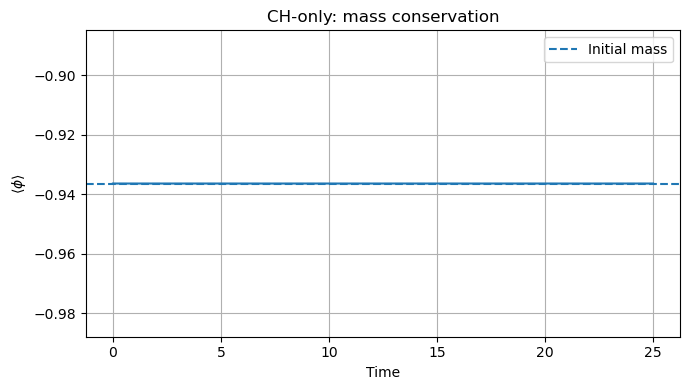

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, mass_history)
plt.axhline(mass_history[0], linestyle="--", label="Initial mass")
plt.xlabel("Time")
plt.ylabel(r"$\langle \phi \rangle$")
plt.title("CH-only: mass conservation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

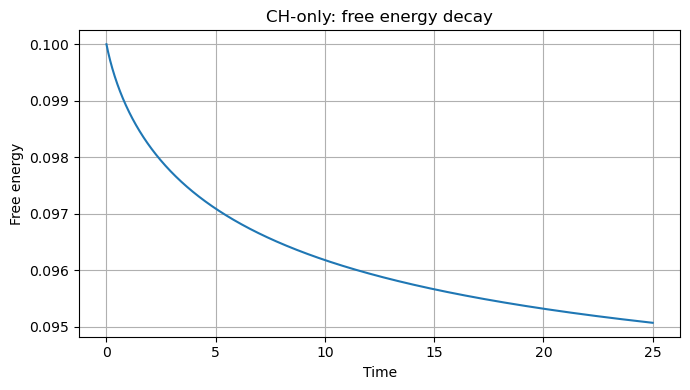

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, free_energy_history)
plt.xlabel("Time")
plt.ylabel("Free energy")
plt.title("CH-only: free energy decay")
plt.grid(True)
plt.tight_layout()
plt.show()

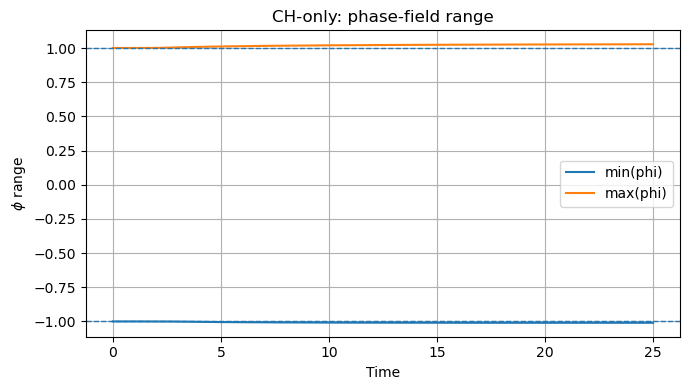

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, min_phi_history, label="min(phi)")
plt.plot(time_history, max_phi_history, label="max(phi)")
plt.axhline(-1, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel(r"$\phi$ range")
plt.title("CH-only: phase-field range")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

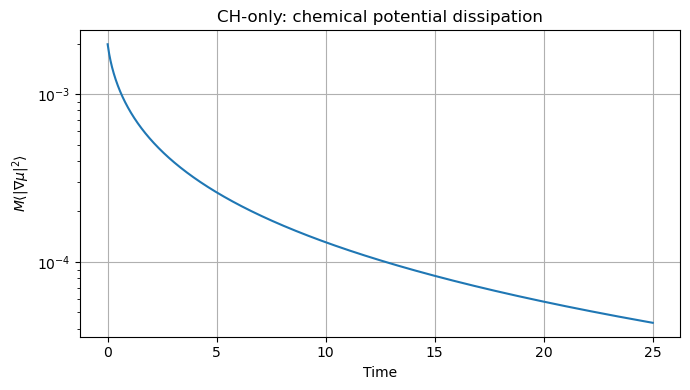

In [18]:
plt.figure(figsize=(7, 4))
plt.semilogy(time_history, dissipation_history + 1e-300)
plt.xlabel("Time")
plt.ylabel(r"$M\langle |\nabla\mu|^2\rangle$")
plt.title("CH-only: chemical potential dissipation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
lambda_phi_real = lambda_phi.real.copy()

print("lambda_phi min =", np.min(lambda_phi_real))
print("lambda_phi max =", np.max(lambda_phi_real))
print("lambda_phi[0,0] =", lambda_phi_real[0, 0])

num_unstable_modes = np.sum(lambda_phi_real > 1e-12)

print("number of unstable modes =", num_unstable_modes)
print("max unstable growth rate =", np.max(lambda_phi_real))

lambda_phi min = -786.1573832364696
lambda_phi max = 0.0062589823261581905
lambda_phi[0,0] = 0.0
number of unstable modes = 576
max unstable growth rate = 0.0062589823261581905


In [20]:
print("M =", M)
print("sigma =", sigma)
print("epsilon =", epsilon)
print("delta_t =", delta_t)
print("T =", T)

M = 1e-05
sigma = 1.0
epsilon = 0.07363107781851078
delta_t = 0.0001
T = 50.0


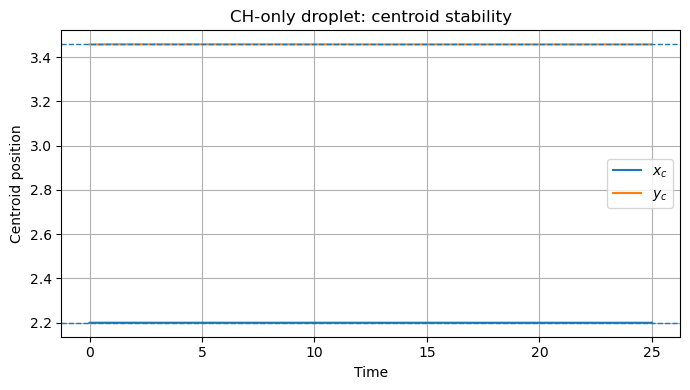

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, centroid_x_history, label=r"$x_c$")
plt.plot(time_history, centroid_y_history, label=r"$y_c$")
plt.axhline(centroid_x_history[0], linestyle="--", linewidth=1)
plt.axhline(centroid_y_history[0], linestyle="--", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Centroid position")
plt.title("CH-only droplet: centroid stability")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

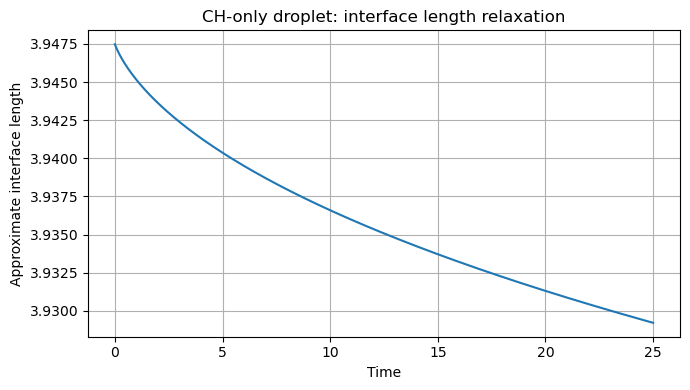

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(time_history, interface_length_history)
plt.xlabel("Time")
plt.ylabel(r"Approximate interface length")
plt.title("CH-only droplet: interface length relaxation")
plt.grid(True)
plt.tight_layout()
plt.show()

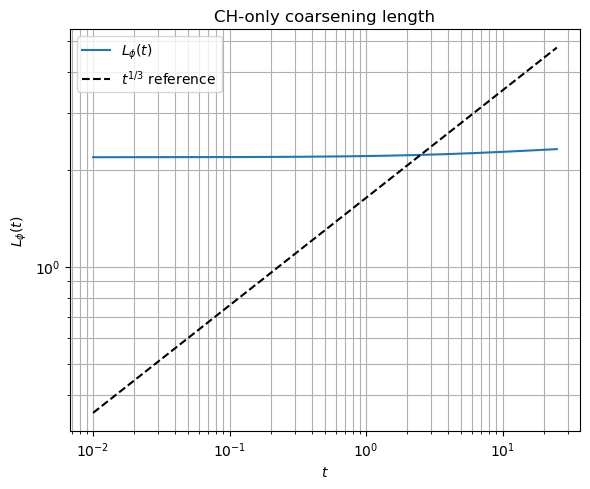

In [23]:
mask = (
    (time_history > 0)
    & np.isfinite(L_coarsening_history)
    & (L_coarsening_history > 0)
)

t_plot = time_history[mask]
L_plot = L_coarsening_history[mask]

plt.figure(figsize=(6, 5))
plt.loglog(t_plot, L_plot, label=r"$L_\phi(t)$")

# choose a reference point away from very early transient
ref_index = max(0, len(t_plot)//10)
t_ref = t_plot[ref_index]
L_ref = L_plot[ref_index]

plt.loglog(
    t_plot,
    L_ref * (t_plot / t_ref)**(1.0 / 3.0),
    "k--",
    label=r"$t^{1/3}$ reference"
)

plt.xlabel(r"$t$")
plt.ylabel(r"$L_\phi(t)$")
plt.title("CH-only coarsening length")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

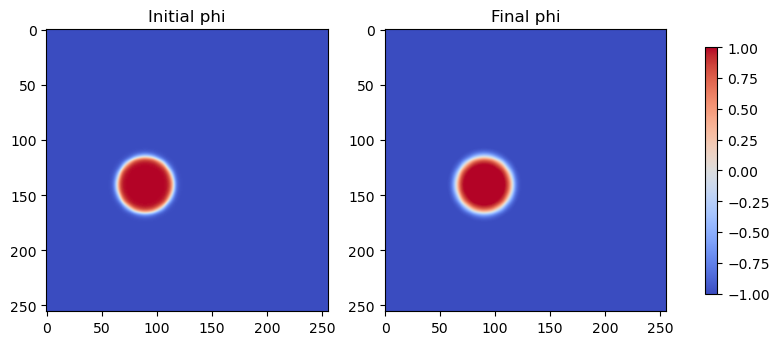

In [24]:
# Initial and final field snapshots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(phi_history[0], vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Initial phi")
axes[0].set_aspect("equal")

im1 = axes[1].imshow(phi_history[-1], vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Final phi")
axes[1].set_aspect("equal")

fig.colorbar(im1, ax=axes, shrink=0.8)
plt.show()

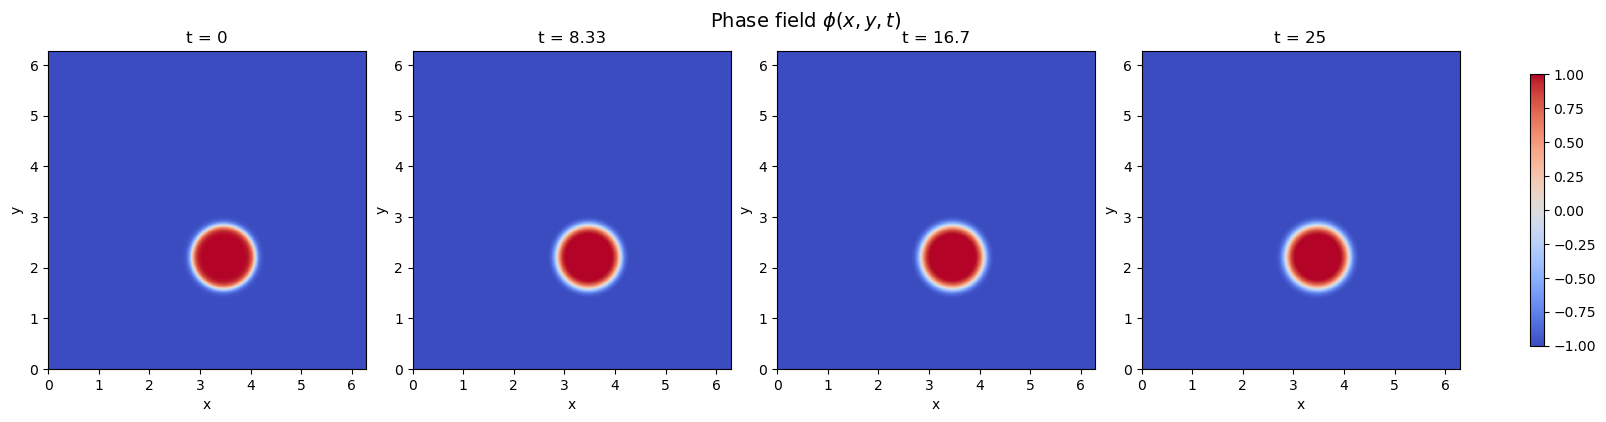

In [25]:
def plot_field_snapshots(
    field_history,
    time_history=None,
    indices=None,
    title=None,
    cmap="coolwarm",
    vmin=None,
    vmax=None,
    extent=None,
    contour_history=None,
    contour_level=0.0,
    contour_color="black",
    figsize=(16, 4),
):
    """
    Plot snapshots of a scalar field in one row.

    Parameters
    ----------
    field_history : array, shape (nt, Nx, Ny)
        Saved scalar field over time.
    time_history : array, optional
        Saved time values.
    indices : list[int], optional
        Indices to plot. If None, plots [0, nt/3, 2nt/3, nt-1].
    title : str, optional
        Figure title.
    cmap : str
        Matplotlib colormap.
    vmin, vmax : float, optional
        Fixed color limits.
    extent : tuple, optional
        Extent for imshow, e.g. (0, Lx, 0, Ly).
    contour_history : array, optional
        If provided, overlays contour_history[index] at contour_level.
        Useful for overlaying phi=0 contour on vorticity.
    contour_level : float
        Contour level.
    contour_color : str
        Contour color.
    figsize : tuple
        Figure size.
    """

    nt = len(field_history)

    if indices is None:
        indices = [0, nt // 3, 2 * nt // 3, nt - 1]

    # Remove duplicates if nt is small
    indices = list(dict.fromkeys(indices))

    fig, axes = plt.subplots(1, len(indices), figsize=figsize, constrained_layout=True)

    if len(indices) == 1:
        axes = [axes]

    # Use global symmetric scale if vmin/vmax not given and field has positive/negative values
    if vmin is None or vmax is None:
        max_abs = np.nanmax(np.abs(field_history[indices]))
        vmin = -max_abs
        vmax = max_abs

    im = None

    for ax, idx in zip(axes, indices):
        field = field_history[idx]

        im = ax.imshow(
            field.T,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            extent=extent,
            aspect="equal",
        )

        if contour_history is not None:
            ax.contour(
                contour_history[idx].T,
                levels=[contour_level],
                colors=contour_color,
                linewidths=1.5,
                extent=extent,
            )

        if time_history is not None:
            ax.set_title(f"t = {time_history[idx]:.3g}")
        else:
            ax.set_title(f"snapshot {idx}")

        ax.set_xlabel("x")
        ax.set_ylabel("y")

    if title is not None:
        fig.suptitle(title, fontsize=14)

    fig.colorbar(im, ax=axes, shrink=0.85)
    plt.show()

plot_field_snapshots(
    phi_history,
    time_history=time_history,
    title=r"Phase field $\phi(x,y,t)$",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    extent=(0, L_x, 0, L_y),
)